# Predicting Health Insurance OLS Model, Feature Engineering and Selection Using VIF and Correlation

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import *

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


## Data Preprocessing

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [5]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


- The dataset has 1338 rows
- The dataset doesn't contain any missing values
- we will have to transform sex, smoker and region to numerical data from categorical data later in the modelling

## EDA

In [6]:
print(df.describe(include='all'))

                age   sex          bmi     children smoker     region  \
count   1338.000000  1338  1338.000000  1338.000000   1338       1338   
unique          NaN     2          NaN          NaN      2          4   
top             NaN  male          NaN          NaN     no  southeast   
freq            NaN   676          NaN          NaN   1064        364   
mean      39.207025   NaN    30.663397     1.094918    NaN        NaN   
std       14.049960   NaN     6.098187     1.205493    NaN        NaN   
min       18.000000   NaN    15.960000     0.000000    NaN        NaN   
25%       27.000000   NaN    26.296250     0.000000    NaN        NaN   
50%       39.000000   NaN    30.400000     1.000000    NaN        NaN   
75%       51.000000   NaN    34.693750     2.000000    NaN        NaN   
max       64.000000   NaN    53.130000     5.000000    NaN        NaN   

             charges  
count    1338.000000  
unique           NaN  
top              NaN  
freq             NaN  
mean    

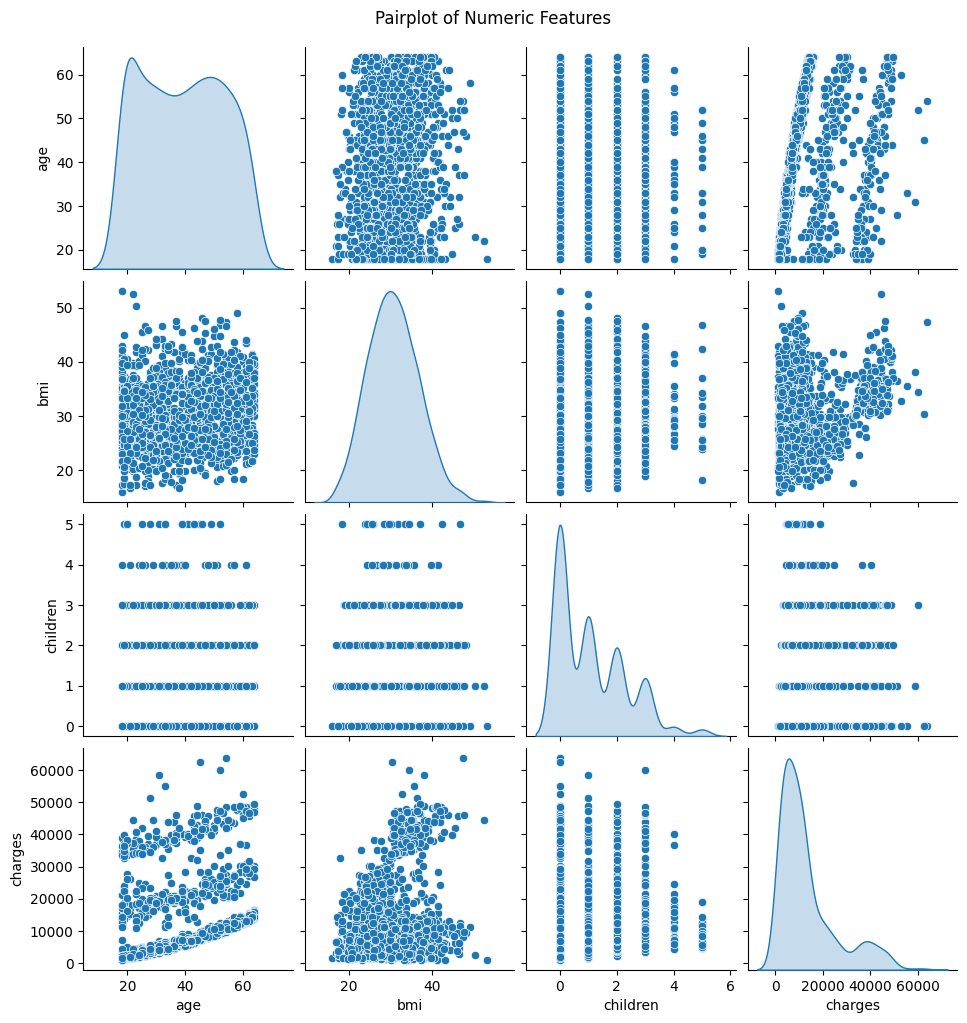

In [7]:
sns.pairplot(df, diag_kind='kde')
plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.show()

## Feature Engineering

In [8]:
df["bmi_sq"] = df["bmi"] ** 2

df["bmi_cat"] = pd.cut(df["bmi"], bins=[0, 18.5, 25, 30, 100],
                       labels=["underweight", "normal", "overweight", "obese"])

df["age_bin"] = pd.cut(df["age"], bins=[17, 25, 35, 45, 55, 65],
                       labels=["18-25", "26-35", "36-45", "46-55", "56-65"])

df["smoker_bmi"] = df["bmi"] * df["smoker"].map({"yes": 1, "no": 0})

## Encoding Categorical Values

In [9]:
df["sex_male"] = df["sex"].map({"male": 1, "female": 0})
df["smoker_yes"] = df["smoker"].map({"yes": 1, "no": 0})

df = pd.get_dummies(df, columns=["region", "bmi_cat", "age_bin"], drop_first=True)

df.drop(columns=["sex", "smoker"], inplace=True)

## Correlation Analysis

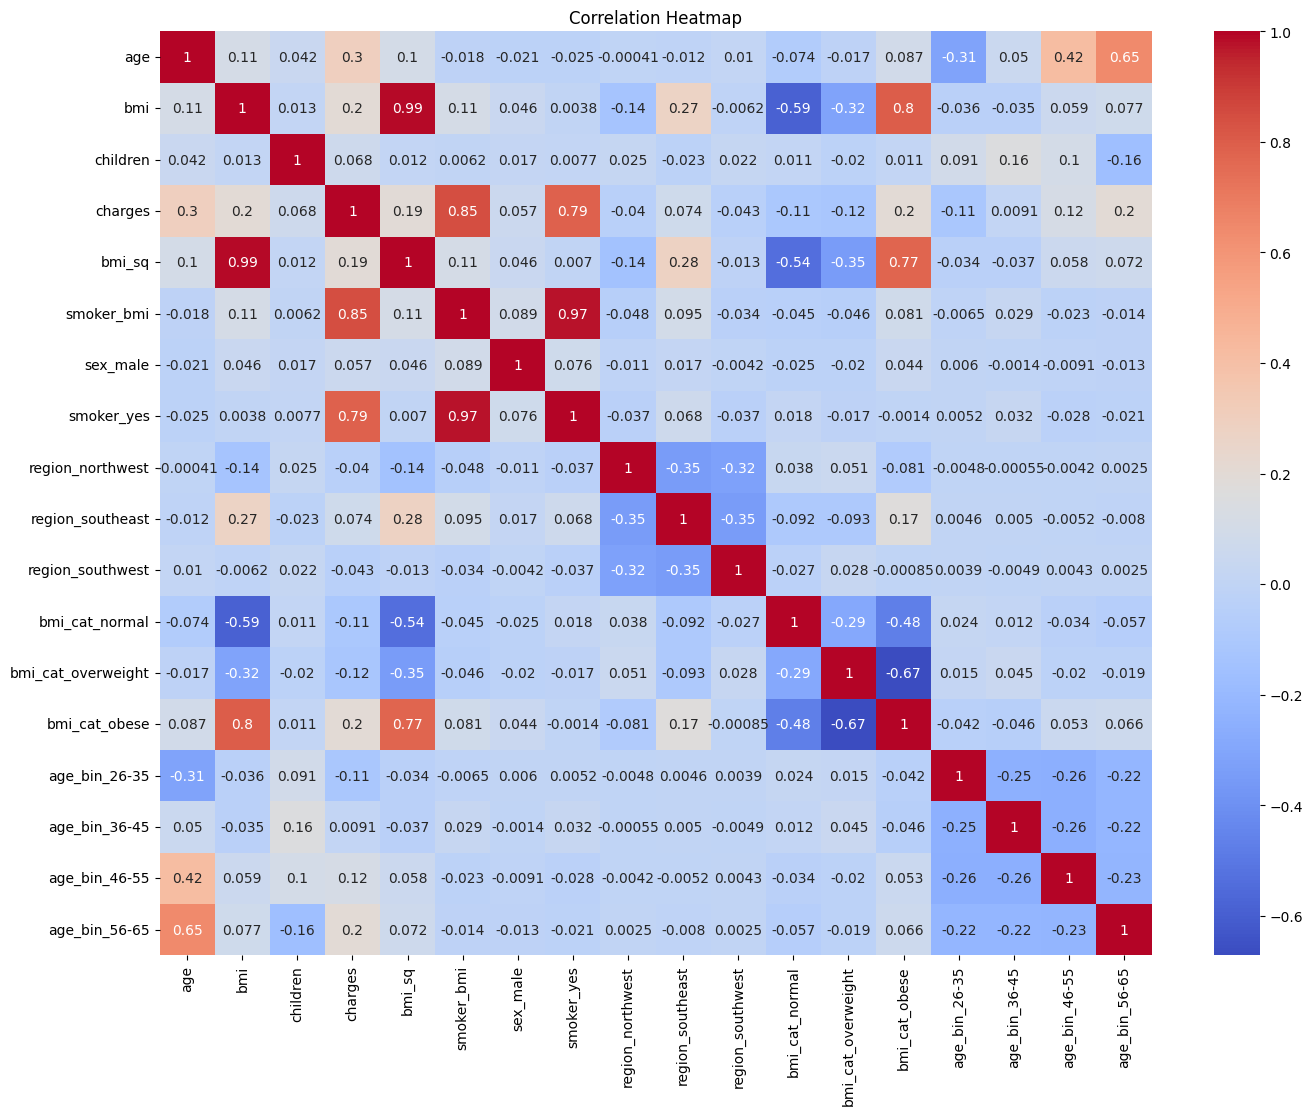

In [10]:
corr = df.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Modelling

In [11]:
X = df.drop(columns=["charges"])
y = df["charges"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1338, 17)
Target shape: (1338,)


In [12]:
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna(axis=1, how='any')

In [13]:
def calculate_vif(X_df):
    X_df = X_df.select_dtypes(include=[np.number])
    X_df = X_df.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    X_const = sm.add_constant(X_df)
    vif = pd.DataFrame()
    vif["feature"] = X_df.columns
    vif["VIF"] = [
        variance_inflation_factor(X_const.values, i + 1)
        for i in range(len(X_df.columns))
    ]
    return vif.sort_values("VIF", ascending=False)

vif_data = calculate_vif(X.select_dtypes(include=[np.number]))
print("\nInitial VIF:\n", vif_data)

X_vif = X.copy()
while True:
    vif_data = calculate_vif(X_vif)
    max_vif = vif_data["VIF"].max()
    if max_vif > 10:
        drop_col = vif_data.iloc[0]["feature"]
        print(f"Dropping {drop_col} (VIF={max_vif:.2f})")
        X_vif = X_vif.drop(columns=[drop_col])
    else:
        break

print("\nFinal VIF:\n", calculate_vif(X_vif))
X = X_vif



Initial VIF:
       feature        VIF
1         bmi  58.889452
3      bmi_sq  58.641110
4  smoker_bmi  25.520818
6  smoker_yes  25.175002
0         age   1.019189
5    sex_male   1.011449
2    children   1.002404
Dropping bmi (VIF=58.89)
Dropping smoker_bmi (VIF=25.45)

Final VIF:
       feature       VIF
0         age  1.013287
2      bmi_sq  1.012725
3    sex_male  1.008816
4  smoker_yes  1.006484
1    children  1.002243


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
models = {
    "LinearRegression": Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]),
    "Ridge": Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))]),
    "Lasso": Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(alpha=0.1))]),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(model, X, y, cv=cv, scoring="r2").mean()

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R² (Test)": r2,
        "R² (CV Mean)": cv_r2
    })

results_df = pd.DataFrame(results)
print("\nModel Performance:")
print(results_df)


Model Performance:
              Model         RMSE          MAE  R² (Test)  R² (CV Mean)
0  LinearRegression  5809.864053  4284.022699   0.782578      0.746386
1             Ridge  5803.123532  4275.171140   0.783082      0.746449
2             Lasso  5809.538201  4283.572577   0.782602      0.746386
3      RandomForest  4557.852131  2563.840137   0.866189      0.835008


In [16]:
X_train_ols = X_train.select_dtypes(include=[np.number]).copy()
X_train_ols = X_train_ols.replace([np.inf, -np.inf], np.nan).fillna(0)
X_train_ols = sm.add_constant(X_train_ols)
y_train_ols = pd.to_numeric(y_train, errors='coerce')
ols_model = sm.OLS(y_train_ols, X_train_ols).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     601.9
Date:                Sun, 05 Oct 2025   Prob (F-statistic):          4.09e-307
Time:                        06:52:26   Log-Likelihood:                -10851.
No. Observations:                1070   AIC:                         2.171e+04
Df Residuals:                    1064   BIC:                         2.174e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6982.5156    748.097     -9.334      0.0

# Conclusion:
- We can see that each model is performing almost the same for the dataset